Fetching historical stock data for AAPL...


/tmp/ipykernel_958/1739268410.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)


Training Data Size: 804 days
Testing Data Size: 201 days

Training Linear Regression model...

--- Model Performance ---
Mean Squared Error (MSE):       4.9459
Root Mean Squared Error (RMSE): 2.2239

Saving plot as 'stock_prediction.png'...
Displaying plot... (Close the plot window to exit)


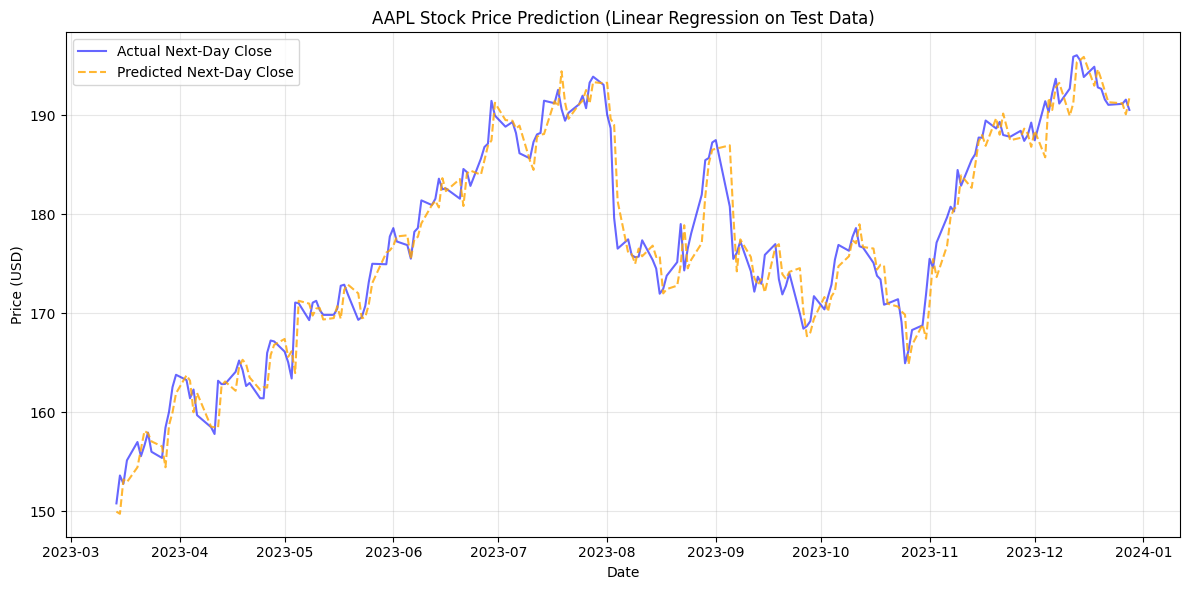

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def main():
    ticker = 'AAPL'
    print(f"Fetching historical stock data for {ticker}...")

    # Download Historical Data
    stock_data = yf.download(ticker, start='2020-01-01', end='2024-01-01', progress=False)

    if stock_data.empty:
        print("Failed to download data.")
        return

    # Handle MultiIndex columns natively returned by newer yfinance versions
    if isinstance(stock_data.columns, pd.MultiIndex):
        try:
            stock_data.columns = stock_data.columns.droplevel('Ticker')
        except Exception:
            stock_data.columns = stock_data.columns.droplevel(1)

    df = stock_data.copy()

    # The goal is to predict the next day's close price, so we shift 'Close' column up by 1
    df['Next_Close'] = df['Close'].shift(-1)

    # Drop rows with NaN values naturally caused by the shifting process
    df.dropna(inplace=True)

    # Use Open, High, Low, and Volume as features
    features = ['Open', 'High', 'Low', 'Volume']
    X = df[features]
    y = df['Next_Close']

    # Split data sequentially so we do not look into the future during training
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    print(f"Training Data Size: {X_train.shape[0]} days")
    print(f"Testing Data Size: {X_test.shape[0]} days")

    # Initialize and fit Linear Regression
    model = LinearRegression()
    print("\nTraining Linear Regression model...")
    model.fit(X_train, y_train)

    # Predict Next_Close values using the test feature set
    predictions = model.predict(X_test)

    # Evaluate model predictions
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print("\n--- Model Performance ---")
    print(f"Mean Squared Error (MSE):       {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

    # Plot Actual vs. Predicted values for testing periods
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test.values, label='Actual Next-Day Close', color='blue', alpha=0.6)
    plt.plot(y_test.index, predictions, label='Predicted Next-Day Close', color='orange', alpha=0.8, linestyle='--')

    plt.title(f'{ticker} Stock Price Prediction (Linear Regression on Test Data)')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    print("\nSaving plot as 'stock_prediction.png'...")
    plt.savefig('stock_prediction.png')

    print("Displaying plot... (Close the plot window to exit)")
    plt.show()
    plt.close()

if __name__ == "__main__":
    main()
